# Extract Sign Synthetic

New format of the PINN takes `data_edge`, `data_sign`, and `data_phys` as an input. 
This program creates these data for synthetic examples based on MRC file as well as pre-calculated phase field. 

In [23]:
import sys
sys.path.append('../src')

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import os
import numpy as np
import matplotlib.pyplot as plt
import jax

### Parameters

In [24]:
shape = "biconcave"
additive = 0.15
missing  = 0.6

str_add = str(additive).replace('.', '')
str_miss = str(missing).replace('.', '')

### Extract Signs and Collocation Points

- Input: pre-calculated phase field
- Output: `data_sign` and `data_phys`

In [ ]:
from pinn.utils import sample_sign_points, sample_collocation_points
from flax.training import checkpoints

num_sign = 10000
num_collocation = 20000
seed = 0
key = jax.random.PRNGKey(seed)
thre_sign = 0.9
sampling_phys = "intensity"

## ===== LOAD PHASE FIELD ========
data_type = "data_0926/clean/sphere"
lambda_1 = 1000000
lambda_2 = 50
step = 10000
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/lambda_{lambda_1}_{lambda_2}")
checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

## ===== SIGN SAMPLING ========
data_sign = sample_sign_points(checkpoint=checkpoint_data, threshold=thre_sign, n_sample=num_sign)

## ===== COLLOCATION POINTS SAMPLING ========
## (A) Uniform sampling
if sampling_phys == "uniform":
    x_train = (jax.random.uniform(key, (num_collocation, 3), minval=-1, maxval=1))
    data_phys = {"points": x_train}

## (B) Intensity-based sampling
if sampling_phys == "intensity":
    data_phys = sample_collocation_points(key, checkpoint_data, num_collocation)

## ===== STORE META DATA ========
meta_sign ={
    "type": "sign",
    "label_meaning": {1: "postive", -1: "negative"},
    "n_sample": num_sign,
    "threshold": thre_sign,
    "phi_fn": checkpoint_path,
}
meta_phys = {
    "type": "phys",
    "n_sample": num_collocation,
    "seed": seed,
    "sampling": sampling_phys,
    "phi_fn": checkpoint_path,
}

print("positive: ", (data_sign["label"] ==  1).sum())
print("nevative: ", (data_sign["label"] == -1).sum())
print("physics: ", data_phys["points"].shape[0])

### Extract Edges
- Input: MRC data (`cryoET_data`)
- Output: `data_edge`

In [33]:
from data_generation.preprocess import downsample_binary_mask_to_fraction, build_data_edge_from_masks
from pinn.cryoet_io import load_mrc_data

GRID_SIZE = 64
edge_min = 0.8
edge_max = 1.0
target_edge = 1.0
target_bulk = 0.2

## ===== LOAD MRC DATA ========
# mrc_file_path = f"../data/synthetic/{shape}.mrc"
mrc_file_path = f"../data/synthetic/combine/{shape}_a{str_add}_m{str_miss}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

## ===== CALCULATE EDGE AND BULK ========
edge    = (cryoET_data >= edge_min) & (cryoET_data <= edge_max)
bulk    = (~edge)

edge = np.asarray(edge)
bulk = np.asarray(bulk)

edge    = downsample_binary_mask_to_fraction(edge, target_frac=target_edge, seed=0)
bulk    = downsample_binary_mask_to_fraction(bulk, target_frac=target_bulk, seed=0)

edge = edge.astype(np.float32)
bulk = bulk.astype(np.float32)

data_edge = build_data_edge_from_masks(
    edge=edge,
    bulk=bulk,
    volume_shape=cryoET_data.shape,
)

## ===== STORE META DATA ========
meta_edge ={
    "type": "edge",
    "label_meaning": {1: "edge", 0: "bulk"},
    "GRID_SIZE": GRID_SIZE,
    "edge_min": edge_min,
    "edge_max": edge_max,
    "target_edge": target_edge,
    "target_bulk": target_bulk,
    "mrc_path": mrc_file_path,
}

print("edge: ",    (data_edge["label"] == 1).sum())
print("bulk: ",    (data_edge["label"] == 0).sum())

edge:  8062
bulk:  52429


### Visualize Data

(<Figure size 1600x400 with 4 Axes>,
 array([<Axes: title={'center': 'Original Image'}>,
        <Axes: title={'center': 'Edge Signals'}>,
        <Axes: title={'center': 'Sign Signals'}>,
        <Axes: title={'center': 'Collocation Points'}>], dtype=object))

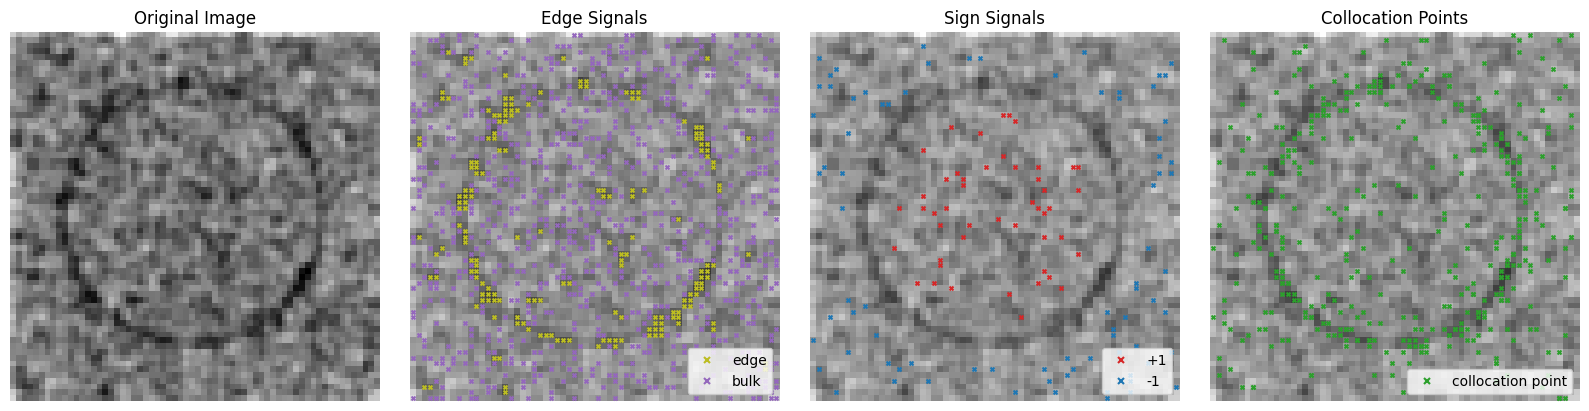

In [27]:
from data_generation.preprocess import plot_sampling_points

axis = "z"
slice_index = 32

plot_sampling_points(cryoET_data, data_edge, data_sign, data_phys, axis=axis)

### Save Data

In [36]:
from pinn.utils import save_pts_data

save_data_dir = f"../data/synthetic/pts_data"
save_pts_data(data_sign, f"{save_data_dir}/sign/s_{shape}.npz", meta_sign)
save_pts_data(data_phys, f"{save_data_dir}/phys/p_{shape}.npz", meta_phys)
save_pts_data(data_edge, f"{save_data_dir}/edge/e_{shape}_a{str_add}_m{str_miss}.npz", meta_edge)

In [35]:
## To reload

import importlib
import data_generation.preprocess as preprocess
import pinn.utils as utils

importlib.reload(preprocess)
importlib.reload(utils)

<module 'pinn.utils' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/notebooks/../src/pinn/utils.py'>